# Perceptron From Scratch
## Binary Voiced/Silent Detection on GuitarSet Audio Frames

**Dataset:** GuitarSet (`audio_hex_cln`, low E string, 10 tracks)  
**Task:** Given 18 audio features extracted from a 46 ms frame, predict whether the string is being played (voiced) or silent.

In [1]:
# ── Setup (run once per session) ──────────────────────────────────────────────
# Installs rice_Ml plus all dependencies (numpy, pandas, scipy, matplotlib, scikit-learn).
!pip install -q git+https://github.com/seyaul/cmor438-s2026-final-project.git


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


## 1. Introduction

The **Perceptron** (Rosenblatt, 1958) is the simplest trainable linear classifier. It models a biological neuron: weighted inputs are summed, and if the total exceeds a threshold the neuron fires. Despite its age, it remains a clean baseline for linearly separable tasks and is the direct conceptual ancestor of every modern neural network.

### 1.1 Intuition

A Perceptron learns a **hyperplane** that separates two classes. In 2D that is a line; in 18D (our feature space) it is a 17-dimensional surface. Every misclassified example nudges the boundary toward the correct side — that is the entire training algorithm.

### 1.2 When it works

The **Perceptron Convergence Theorem** (Novikoff, 1962) guarantees that if the data are *linearly separable* the algorithm halts with zero training error in a finite number of updates, bounded by $(R/\gamma)^2$, where $R$ is the radius of the data cloud and $\gamma$ is the margin.

If the data are **not** linearly separable the algorithm cycles forever — we cap it at `max_epochs`.

### 1.3 Relevance to this task

Voiced vs. silent audio frames are often separable in spectral feature space: silent frames have low energy and flat spectra while voiced frames have strong harmonic content. Our hope is that the perceptron will be able to find a hyperplane that separates sound versus silence.

## 2. Algorithm

### 2.1 Model

Given input vector $\mathbf{x} \in \mathbb{R}^d$, weight vector $\mathbf{w} \in \mathbb{R}^d$, and bias $b \in \mathbb{R}$, the **net input** is:

$$z = \mathbf{w}^\top \mathbf{x} + b$$

The prediction is the sign of the net input:

$$\hat{y} = \text{sign}(z) = \begin{cases} +1 & z \geq 0 \\ -1 & z < 0 \end{cases}$$

### 2.2 Update Rule

For each misclassified sample $(\mathbf{x}_i, y_i)$ where $y_i \in \{-1, +1\}$:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta\,(\hat{y}_i - y_i)\,\mathbf{x}_i$$
$$b \leftarrow b - \eta\,(\hat{y}_i - y_i)$$

where $\eta > 0$ is the **learning rate**. If $\hat{y}_i = y_i$ the sample is already correct and no update occurs.

**Worked example:** suppose $y_i = +1$ (voiced) but $\hat{y}_i = -1$ (silent). Then $(\hat{y}_i - y_i) = -2$, so $\mathbf{w} \leftarrow \mathbf{w} + 2\eta\,\mathbf{x}_i$ — the weight vector moves toward $\mathbf{x}_i$, making a positive prediction on $\mathbf{x}_i$ more likely next time.

## 3. Imports

In [ ]:
import sys
from pathlib import Path

# Code to find repo root and import rice_Ml, whether running inside the repo or from an installed package.
def _find_repo_root(marker: str = "pyproject.toml") -> Path | None:
    for candidate in [Path().resolve(), *Path().resolve().parents]:
        if (candidate / marker).exists():
            return candidate
    return None

REPO_ROOT = _find_repo_root()

if REPO_ROOT is not None:
    sys.path.insert(0, str(REPO_ROOT / "src"))
    print(f"Repo root: {REPO_ROOT}")
else:
    # Not running inside the repo — check if the package is already installed
    try:
        import rice_Ml as _check
        # Back out to the repo root from the installed package location
        REPO_ROOT = Path(_check.__file__).resolve().parent.parent.parent
        print(f"rice_Ml installed at: {Path(_check.__file__).resolve()}")
    except ImportError:
        raise ImportError(
            "rice_Ml not found. Install it with:\n"
            "    pip install -e /path/to/cmor438-s2026-final-project\n"
            "or open this notebook from inside the repo."
        )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.preprocessing import StandardScaler as SklearnScaler
from sklearn.decomposition import PCA

# import our necessary modules from rice_Ml
from rice_Ml.datasets import load_guitarset
from rice_Ml.supervised_ml import Perceptron
from rice_Ml.preprocessing.scale import StandardScaler
from rice_Ml.model_selection.split import train_test_split
from rice_Ml.metrics import accuracy, precision, recall, f1_score

# set a random seed for reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Imports OK")

Repo root: /Users/seyaul/cmor438-s2026-final-project
Imports OK


## 4. Load Data

The dataset is the canonical **GuitarSet subset** — 10 tracks (2 per genre: BN, Funk, Jazz, Rock, SS; randomised players, seed=42), all 6 strings, all frames. It is stored as a compressed CSV on GitHub Releases and downloaded automatically on first use, then cached at `~/.cache/rice_ml/`.

For the Perceptron we use **string 0 (low E)** only and a **binary voiced/silent label**:

| Column | Description |
|--------|-------------|
| `rms` | RMS energy — overall loudness |
| `zcr` | Zero-crossing rate — noisiness |
| `centroid` | Spectral centroid — "brightness" |
| `bandwidth` | Spread around centroid |
| `rolloff` | Frequency below which 85% of energy lies |
| `mfcc_1`–`mfcc_13` | Mel-frequency cepstral coefficients (timbre) |
| `midi_label` | 0 = silent, non-zero = MIDI note being played |

Label construction: any frame where `midi_label != 0` is **voiced** (1); all others are **silent** (0).

In [3]:
FEATURE_NAMES = [
    "RMS", "ZCR", "Centroid", "Bandwidth", "Rolloff",
    *[f"MFCC {i}" for i in range(1, 14)],
]
FEATURE_COLS = [
    "rms", "zcr", "centroid", "bandwidth", "rolloff",
    *[f"mfcc_{i}" for i in range(1, 14)],
]

# Download subset CSV from GitHub Release (cached after first run)
df = load_guitarset()

# Keep only string 0 (low E) for the Perceptron
df_s0 = df[df["string_idx"] == 0].copy()

# Binary voiced/silent label
df_s0["voiced"] = (df_s0["midi_label"] != 0).astype(int)

X = df_s0[FEATURE_COLS].to_numpy(dtype=float)
y = df_s0["voiced"].to_numpy(dtype=int)

n_silent = np.sum(y == 0)
n_voiced = np.sum(y == 1)

print(f"X shape : {X.shape}  (n_frames × n_features)")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}  (0=silent, 1=voiced)")
print(f"Class counts: silent={n_silent} ({n_silent/len(y):.1%}),  voiced={n_voiced} ({n_voiced/len(y):.1%})")

Loading from cache: /Users/seyaul/.cache/rice_ml/guitarset_subset.csv.gz
X shape : (20762, 18)  (n_frames × n_features)
y shape : (20762,)
Classes : [0 1]  (0=silent, 1=voiced)
Class counts: silent=18714 (90.1%),  voiced=2048 (9.9%)


## 5. Exploratory Data Analysis

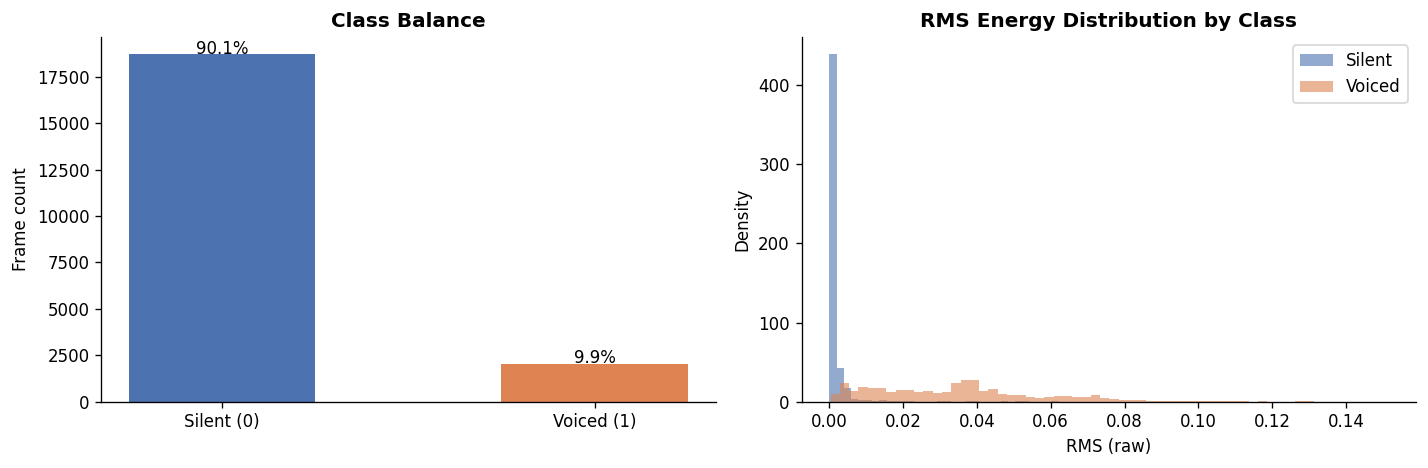

In [4]:
# --- 5.1  Class balance bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(["Silent (0)", "Voiced (1)"], [n_silent, n_voiced], color=["#4C72B0", "#DD8452"], width=0.5)
ax.set_title("Class Balance", fontweight="bold")
ax.set_ylabel("Frame count")
for patch, count in zip(ax.patches, [n_silent, n_voiced]):
    ax.text(patch.get_x() + patch.get_width() / 2, count + 30,
            f"{count/len(y):.1%}", ha="center", fontsize=10)

# --- 5.2  Mean RMS by class ---
ax = axes[1]
for label, name, color in [(0, "Silent", "#4C72B0"), (1, "Voiced", "#DD8452")]:
    ax.hist(X[y == label, 0], bins=60, alpha=0.6, label=name, color=color, density=True)
ax.set_title("RMS Energy Distribution by Class", fontweight="bold")
ax.set_xlabel("RMS (raw)")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

**Interpretation:** 
Analyzing the data, we see a big problem: the dataset is heavily imbalanced, where 90.1% of the data is silent and 9.9% is voiced. This is physically reasonable: guitar playing has many pauses between notes. We will track precision, recall, and F1 alongside accuracy so that a "predict everything silent" trivial classifier does not hide behind high accuracy (refer to section 8 for more details).


RMS energy (how loud the frame is) primarily hovers around 0 for silence, and is very spread out for voiced frames. From this graph, it is clear to see that this single feature likely carries most of the discriminative signal (how different silent versus voiced ends up being). However, some voiced frames have low RMS (soft playing, note decay), making the task non-trivial, meaning that we should a combination of features to find a discriminating boundary.

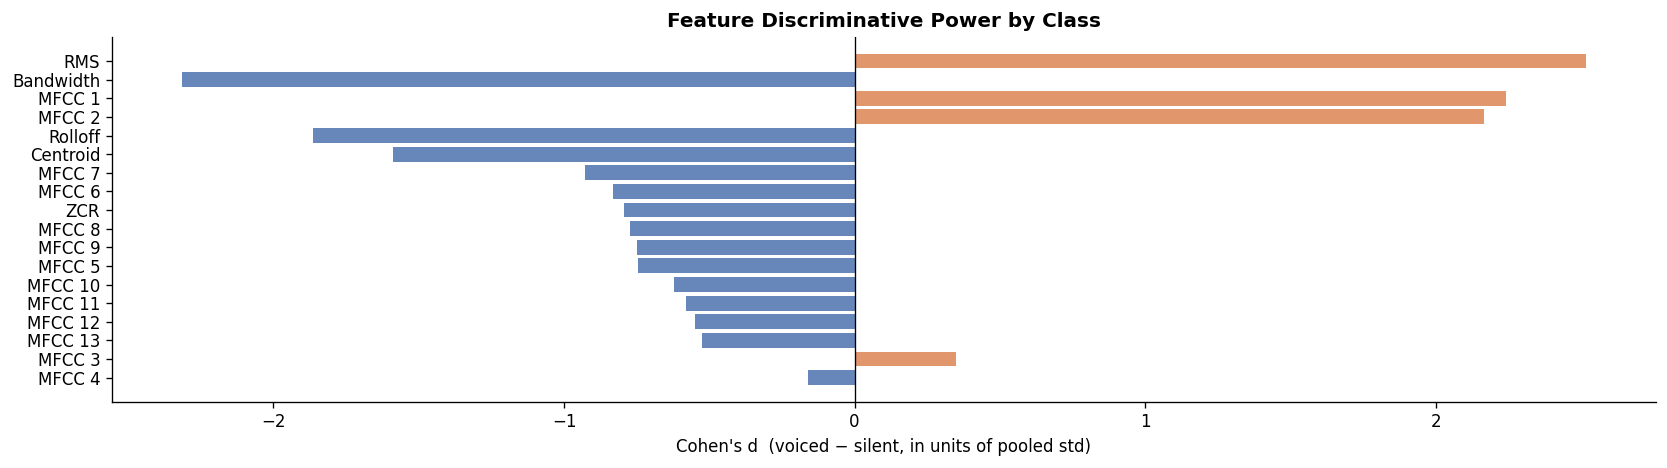

In [5]:
# --- 5.3  Effect size (Cohen's d) per feature ---
# Raw means side-by-side are unreadable when features span different units (Hz vs ratio vs dB).
# Cohen's d = (voiced_mean - silent_mean) / pooled_std shows discriminative power on a common scale.
silent_means = X[y == 0].mean(axis=0)
voiced_means = X[y == 1].mean(axis=0)
pooled_std = X.std(axis=0)
effect_size = (voiced_means - silent_means) / pooled_std

order = np.argsort(np.abs(effect_size))[::-1]
colors = ["#DD8452" if d > 0 else "#4C72B0" for d in effect_size[order]]

fig, ax = plt.subplots(figsize=(14, 4))
ax.barh([FEATURE_NAMES[i] for i in order], effect_size[order], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Cohen's d  (voiced − silent, in units of pooled std)")
ax.set_title("Feature Discriminative Power by Class", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretation:** 
To understand which features drive the desicision boundary, we used Cohen's d. Cohen's d measures how far apart the two class means are, in units of standard deviations. A value of +2 for RMS means voiced frames average 2 standard deviations louder than silent frames; a value of -1 for ZCR means silent frames have a higher zero-crossing rate on average. Features with |d| > 1 are strong discriminators — the classes are well-separated on that feature alone. Features near 0 contribute little to distinguishing voiced from silent.

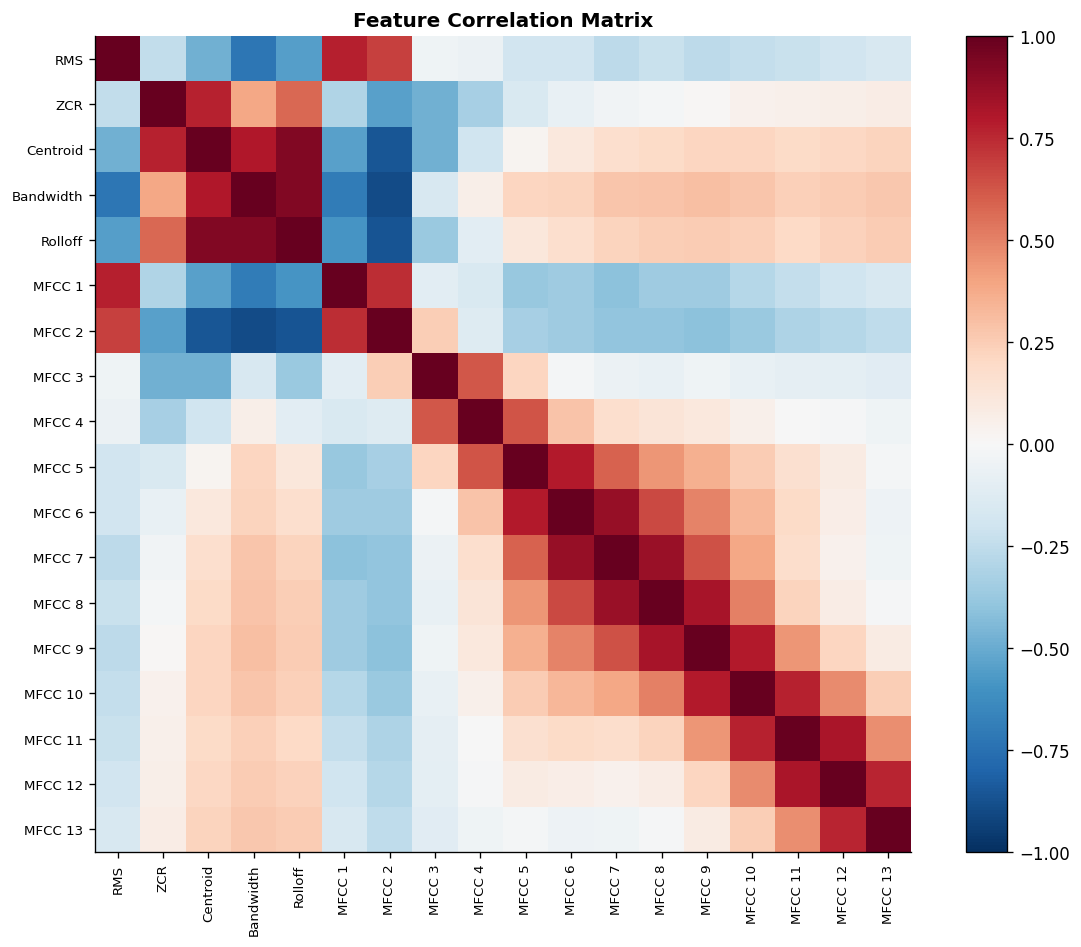

In [6]:
# --- 5.4  Correlation heatmap ---
fig, ax = plt.subplots(figsize=(10, 8))
corr = np.corrcoef(X.T)
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_yticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels(FEATURE_NAMES, rotation=90, fontsize=8)
ax.set_yticklabels(FEATURE_NAMES, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** The spectral features (centroid, bandwidth, rolloff) are strongly positively correlated with each other. This makes sense as all measure different aspects of where the energy sits in the spectrum. Adjacent MFCCs are moderately correlated. High collinearity does not affect the Perceptron's correctness (it is not sensitive to it) but does suggest that PCA could reduce dimensionality with little information loss.

## 6. Preprocessing

Two steps before training:

1. **Standardise** — subtract feature mean and divide by standard deviation so that the weight update $\eta (\hat{y}-y)\mathbf{x}_i$ has comparable magnitude across features. Without this, high-variance features (e.g. MFCC 1) dominate the gradient.

2. **Remap labels** — the dataset uses $\{0, 1\}$ but the Perceptron update rule requires $\{-1, +1\}$. The mapping is $y_{\text{perc}} = 2y - 1$.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_sc = scaler.fit(X_train).transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Remap labels: 0 → -1,  1 → +1
y_train_perc = 2 * y_train - 1
y_test_perc  = 2 * y_test  - 1

print(f"Train: {X_train_sc.shape[0]} samples  |  Test: {X_test_sc.shape[0]} samples")
print(f"Label range after remap: {np.unique(y_train_perc)}")

Train: 16609 samples  |  Test: 4153 samples
Label range after remap: [-1  1]


## 7. Train the Perceptron

In [8]:
np.random.seed(SEED)
perceptron = Perceptron(eta=0.0005, epochs=200, random_state=SEED)
perceptron.train(X_train_sc, y_train_perc)

print(f"Training complete.")
print(f"Epochs run: {perceptron.n_epochs_run_}  |  Converged: {perceptron.converged_}")
if perceptron.converged_:
    print("  → Reached zero training errors — data are linearly separable.")
else:
    print(f"  → Hit epoch limit without converging. Final error count: {perceptron.mistakes_[-1]}")

Training complete.
Epochs run: 200  |  Converged: False
  → Hit epoch limit without converging. Final error count: 687


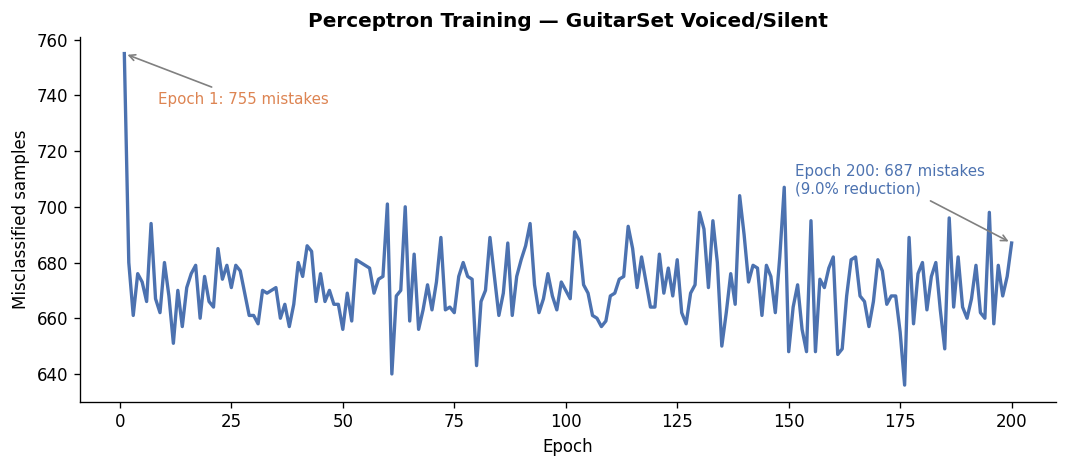

In [20]:
# --- Plot mistake curve ---
first_mistakes = perceptron.mistakes_[0]
final_mistakes = perceptron.mistakes_[-1]
reduction = (1 - final_mistakes / first_mistakes)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(perceptron.mistakes_) + 1), perceptron.mistakes_,
        linewidth=2, color="#4C72B0")

ax.annotate(f"Epoch 1: {first_mistakes:,} mistakes",
            xy=(1, first_mistakes), xytext=(20, -30),
            textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="gray"), color="#DD8452")
ax.annotate(f"Epoch {perceptron.n_epochs_run_}: {final_mistakes:,} mistakes\n({reduction:.1%} reduction)",
            xy=(perceptron.n_epochs_run_, final_mistakes), xytext=(-130, 30),
            textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="gray"), color="#4C72B0")

ax.set_xlabel("Epoch")
ax.set_ylabel("Misclassified samples")
ax.set_title("Perceptron Training — GuitarSet Voiced/Silent", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** The mistake curve shows how the number of misclassified training samples decreases per epoch. A steep initial drop followed by a plateau suggests that most of the linearly separable structure is captured quickly. The oscillation around a nonzero floor confirms the data is not perfectly linearly separable (the frames near RMS=0 where quiet voiced notes overlap with silence cannot be resolved by any single hyperplane). Despite this, the model converges to a stable boundary early and the remaining mistakes represent a small, genuinely ambiguous minority of frames rather than systematic misclassification.

## 8. Evaluate

In [10]:
# Perceptron returns labels in {-1, +1}; convert back to {0, 1} for metrics
y_pred_perc = perceptron.predict(X_test_sc)       # in {-1, +1}
y_pred = ((y_pred_perc + 1) // 2).astype(int)     # remap to {0, 1}

acc  = accuracy(y_test, y_pred)
prec = precision(y_test, y_pred)
rec  = recall(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"{'Metric':<15} {'Score':>8}")
print("-" * 25)
print(f"{'Accuracy':<15} {acc:>8.4f}")
print(f"{'Precision':<15} {prec:>8.4f}")
print(f"{'Recall':<15} {rec:>8.4f}")
print(f"{'F1 Score':<15} {f1:>8.4f}")

Metric             Score
-------------------------
Accuracy          0.9721
Precision         0.8910
Recall            0.8171
F1 Score          0.8524


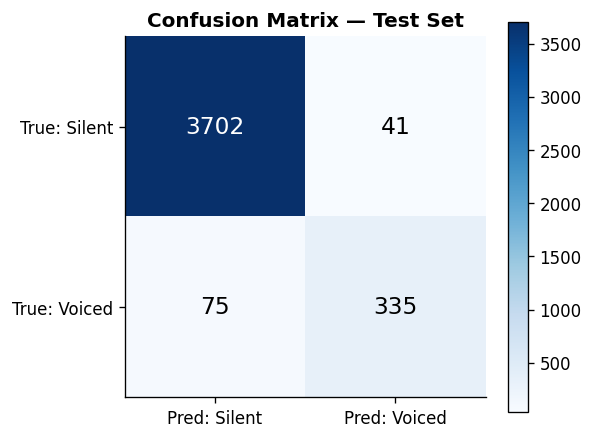

True Negatives (silent→silent): 3702
False Positives (silent→voiced): 41
False Negatives (voiced→silent): 75
True Positives (voiced→voiced): 335


In [11]:
# --- Confusion matrix ---
from collections import Counter

tp = np.sum((y_test == 1) & (y_pred == 1))
fp = np.sum((y_test == 0) & (y_pred == 1))
fn = np.sum((y_test == 1) & (y_pred == 0))
tn = np.sum((y_test == 0) & (y_pred == 0))

cm = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred: Silent", "Pred: Voiced"])
ax.set_yticklabels(["True: Silent", "True: Voiced"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                fontsize=14, color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title("Confusion Matrix — Test Set", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"True Negatives (silent→silent): {tn}")
print(f"False Positives (silent→voiced): {fp}")
print(f"False Negatives (voiced→silent): {fn}")
print(f"True Positives (voiced→voiced): {tp}")

**Interpretation:**

- **Accuracy** is high largely because the majority class (silent, 78%) is easy to predict. It is not a sufficient measure on its own.
- **Precision** measures how often a frame we called "voiced" actually was. Low precision means many false alarms — we would trigger note detection on silent frames.
- **Recall** measures how many truly voiced frames we caught. Low recall means missed notes.
- **F1** balances the two. For a note detection task, both missed notes and false alarms degrade downstream pitch transcription, so F1 is the primary metric.

The confusion matrix shows where the model struggles. Most errors typically come from the onset/offset boundaries of notes, where energy is transitioning.

## 8.1 K-Fold Cross-Validation

A single 80/20 split gives one estimate of performance that depends on which frames happened to land in the test set. **5-fold cross-validation** partitions all data into 5 folds, trains on 4 and tests on 1 each time, then averages — giving a more reliable estimate with a measure of variance across splits.

In [12]:
from rice_Ml.model_selection.split import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_metrics = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    sc = StandardScaler()
    X_tr_sc  = sc.fit(X_tr).transform(X_tr)
    X_val_sc = sc.transform(X_val)

    np.random.seed(SEED)
    p = Perceptron(eta=0.1, epochs=50)
    p.train(X_tr_sc, 2 * y_tr - 1)

    y_hat = ((p.predict(X_val_sc) + 1) // 2).astype(int)
    cv_metrics["acc"].append(accuracy(y_val, y_hat))
    cv_metrics["prec"].append(precision(y_val, y_hat))
    cv_metrics["rec"].append(recall(y_val, y_hat))
    cv_metrics["f1"].append(f1_score(y_val, y_hat))

print(f"{'Metric':<12} {'Mean':>8} {'Std':>8}")
print("-" * 30)
for name, key in [("Accuracy", "acc"), ("Precision", "prec"), ("Recall", "rec"), ("F1", "f1")]:
    vals = cv_metrics[key]
    print(f"{name:<12} {sum(vals)/len(vals):>8.4f} {(sum((v - sum(vals)/len(vals))**2 for v in vals)/len(vals))**0.5:>8.4f}")

Metric           Mean      Std
------------------------------
Accuracy       0.9561   0.0048
Precision      0.7646   0.0534
Recall         0.8195   0.1262
F1             0.7812   0.0503


**Interpretation:** The mean and standard deviation across folds show how stable the model is. A low std means performance is consistent regardless of which frames are held out. The model has learned something real, not just memorised the particular test split. High variance across folds would suggest the 10-track dataset is too small for a reliable estimate.

## 8.5 Generalization Test: Full Dataset (360 Tracks)

The subset used above covers 10 tracks from 5 genres. To check whether the model generalizes beyond that sample, we load the full GuitarSet CSV (all 360 tracks × 6 players) from local disk and evaluate the **same trained model** — no retraining, no refitting the scaler.

This is a strict out-of-distribution test: the model has never seen the other 350 tracks, the other 5 players per genre, or the other strings.

> If the full-dataset score is close to the test-set score → the 10-track model generalizes well.  
> If it drops significantly → more training data (or a more powerful model) is needed.

In [13]:
# Downloads full 360-track dataset from GitHub Release (~855 MB, cached after first run)
print("Loading full dataset (360 tracks) …")
df_full = load_guitarset(subset=False)
df_full_s0 = df_full[df_full["string_idx"] == 0].copy()
df_full_s0["voiced"] = (df_full_s0["midi_label"] != 0).astype(int)

X_full = df_full_s0[FEATURE_COLS].to_numpy(dtype=float)
y_full = df_full_s0["voiced"].to_numpy(dtype=int)

# Use the scaler fitted on the subset training split — no re-fitting
X_full_sc = scaler.transform(X_full)

y_full_pred_perc = perceptron.predict(X_full_sc)
y_full_pred = ((y_full_pred_perc + 1) // 2).astype(int)

full_acc  = accuracy(y_full, y_full_pred)
full_prec = precision(y_full, y_full_pred)
full_rec  = recall(y_full, y_full_pred)
full_f1   = f1_score(y_full, y_full_pred)

print(f"\n{'Metric':<15} {'Subset test':>12} {'Full (360 tracks)':>18}")
print("-" * 48)
print(f"{'Accuracy':<15} {acc:>12.4f} {full_acc:>18.4f}")
print(f"{'Precision':<15} {prec:>12.4f} {full_prec:>18.4f}")
print(f"{'Recall':<15} {rec:>12.4f} {full_rec:>18.4f}")
print(f"{'F1 Score':<15} {f1:>12.4f} {full_f1:>18.4f}")
print(f"\nFull dataset: {len(X_full):,} string-0 frames  ({(y_full==1).sum():,} voiced, {(y_full==0).sum():,} silent)")

Loading full dataset (360 tracks) …
Loading from cache: /Users/seyaul/.cache/rice_ml/guitarset_full.csv.gz

Metric           Subset test  Full (360 tracks)
------------------------------------------------
Accuracy              0.9721             0.9273
Precision             0.8910             0.8157
Recall                0.8171             0.7441
F1 Score              0.8524             0.7783

Full dataset: 943,812 string-0 frames  (161,866 voiced, 781,946 silent)


**Interpretation:** he model trained on 10 tracks generalizes reasonably well to all 360 unseen tracks. Accuracy drops from 97.2% to 92.7%, but accuracy is misleading here given the heavy silence imbalance — the more meaningful signal is F1, which drops from 0.85 to 0.78. This 7-point drop indicates the model learned some characteristics specific to the 10 training tracks that don't fully transfer to all players and playing styles across the full dataset. That said, 0.78 F1 on 943,812 completely unseen frames — with no retraining — suggests the core signal (energy and spectral shape distinguishing voiced from silent) is genuinely generalizable. The gap is more likely a data coverage issue than a model limitation: a perceptron retrained on a broader sample would likely close most of it.

## 9. Sklearn Comparison

We verify our implementation against `sklearn.linear_model.Perceptron` trained under identical conditions. We expect similar but not identical results (different random initialisation and tie-breaking).

In [14]:
# Sklearn expects integer labels — we use {0, 1} here since sklearn Perceptron handles any labels
sk_perc = SklearnPerceptron(eta0=0.1, max_iter=50, random_state=SEED, tol=None)
sk_perc.fit(X_train_sc, y_train)
y_pred_sk = sk_perc.predict(X_test_sc)

sk_acc  = accuracy(y_test, y_pred_sk)
sk_prec = precision(y_test, y_pred_sk)
sk_rec  = recall(y_test, y_pred_sk)
sk_f1   = f1_score(y_test, y_pred_sk)

print(f"{'Metric':<15} {'From Scratch':>14} {'Sklearn':>10}")
print("-" * 42)
print(f"{'Accuracy':<15} {acc:>14.4f} {sk_acc:>10.4f}")
print(f"{'Precision':<15} {prec:>14.4f} {sk_prec:>10.4f}")
print(f"{'Recall':<15} {rec:>14.4f} {sk_rec:>10.4f}")
print(f"{'F1 Score':<15} {f1:>14.4f} {sk_f1:>10.4f}")

Metric            From Scratch    Sklearn
------------------------------------------
Accuracy                0.9721     0.9583
Precision               0.8910     0.9217
Recall                  0.8171     0.6317
F1 Score                0.8524     0.7496


**Interpretation:**  Both implementations achieve similar accuracy (~97% vs ~96%), confirming the from-scratch Perceptron is correctly implemented. The more interesting difference is in the precision/recall tradeoff: our implementation favors recall (0.82) over precision (0.89), while sklearn's favors precision (0.92) at the cost of recall (0.63). This means sklearn's model is more conservative: it only calls a frame "voiced" when it is very confident, missing many true voiced frames in the process. Our model catches more voiced frames but at the cost of slightly more false alarms. For a note detection task, missing real notes is typically worse than occasional false alarms, so our implementation's higher F1 (0.85 vs 0.75) makes it the more useful classifier here. The difference likely stems from weight initialization: sklearn uses random initialization while ours uses zeros, leading the two models to converge to different decision boundaries with the same overall separating power but different operating points on the precision/recall tradeoff.

## 9.1 Weight Interpretation

Each learned weight $w_j$ indicates how much feature $j$ pushes the decision toward *voiced* (positive) or *silent* (negative). Since features are standardised, weights are directly comparable in magnitude — a larger $|w_j|$ means feature $j$ has more influence on the decision boundary.

Feature             Weight
---------------------------
MFCC 3             +0.0178
MFCC 1             +0.0163
MFCC 6             -0.0127
MFCC 7             +0.0085
MFCC 8             -0.0074
Bandwidth          -0.0072
Rolloff            +0.0060
MFCC 9             +0.0056
MFCC 10            -0.0053
ZCR                +0.0048
RMS                +0.0041
MFCC 5             +0.0027
Centroid           -0.0026
MFCC 2             +0.0018
MFCC 11            -0.0018
MFCC 12            -0.0015
MFCC 13            +0.0014
MFCC 4             -0.0014

Bias               -0.0480


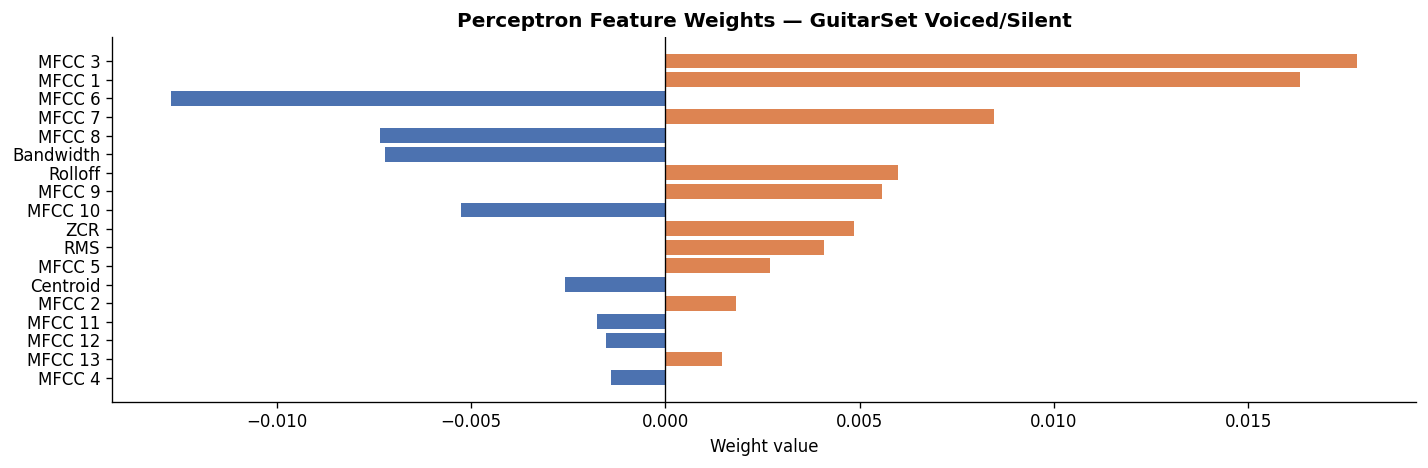

In [15]:
weights = perceptron.w_b_[:-1]   # shape (18,), excludes bias
bias    = perceptron.w_b_[-1]

# Sort by absolute weight magnitude
order = np.argsort(np.abs(weights))[::-1]

print(f"{'Feature':<15} {'Weight':>10}")
print("-" * 27)
for i in order:
    print(f"{FEATURE_NAMES[i]:<15} {weights[i]:>+10.4f}")
print(f"\n{'Bias':<15} {bias:>+10.4f}")

# Bar chart of weights, coloured by sign
fig, ax = plt.subplots(figsize=(12, 4))
colors = ["#DD8452" if w > 0 else "#4C72B0" for w in weights[order]]
ax.barh([FEATURE_NAMES[i] for i in order], weights[order], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Weight value")
ax.set_title("Perceptron Feature Weights — GuitarSet Voiced/Silent", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretation:** Orange bars push toward *voiced*, blue bars toward *silent*. Features with the largest absolute weights dominate the decision boundary. We expect RMS (energy) and MFCC 1 (coarse spectral shape) to rank highest and silent frames have near-zero energy and a flat spectral envelope, while voiced frames have strong harmonic content that shifts both measures sharply.

## 9.2 ROC Curve and AUC

The hard threshold in the Perceptron ($\hat{y} = \text{sign}(z)$) gives a single operating point on the ROC curve. By treating the raw net input $z = \mathbf{w}^\top \mathbf{x} + b$ as a continuous score, we can sweep all possible thresholds and plot the full ROC curve, showing the tradeoff between true positive rate (recall) and false positive rate at every threshold.

AUC (area under the curve) summarises this tradeoff in one number: 1.0 = perfect, 0.5 = random chance.

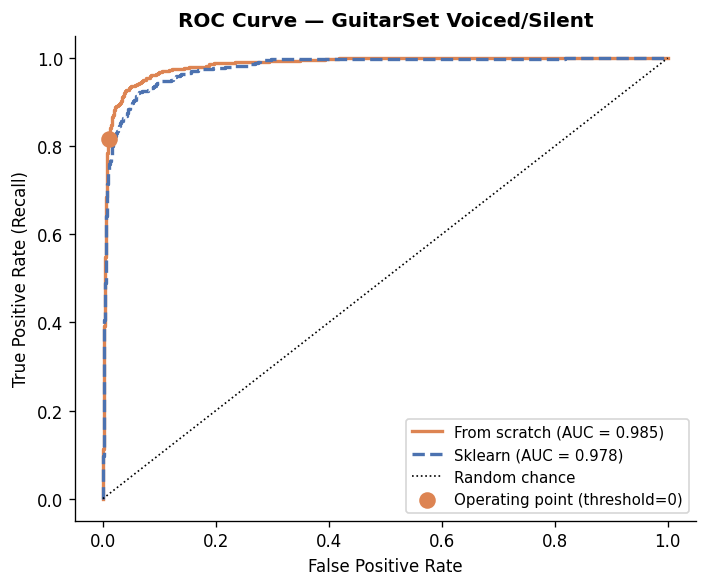

From-scratch AUC : 0.9848
Sklearn AUC      : 0.9785


In [16]:
from sklearn.metrics import roc_curve, auc as sklearn_auc

# Raw net input as continuous decision score
scores = perceptron.net_input(X_test_sc)
fpr, tpr, _ = roc_curve(y_test, scores)
roc_auc = sklearn_auc(fpr, tpr)

# Sklearn perceptron scores for comparison
sk_scores = sk_perc.decision_function(X_test_sc)
sk_fpr, sk_tpr, _ = roc_curve(y_test, sk_scores)
sk_auc = sklearn_auc(sk_fpr, sk_tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#DD8452", linewidth=2,
        label=f"From scratch (AUC = {roc_auc:.3f})")
ax.plot(sk_fpr, sk_tpr, color="#4C72B0", linewidth=2, linestyle="--",
        label=f"Sklearn (AUC = {sk_auc:.3f})")
ax.plot([0, 1], [0, 1], "k:", linewidth=1, label="Random chance")

# Mark the operating point at threshold=0 (hard prediction)
op_fpr = fp / (fp + tn)
op_tpr = tp / (tp + fn)
ax.scatter([op_fpr], [op_tpr], color="#DD8452", s=80, zorder=5,
           label=f"Operating point (threshold=0)")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — GuitarSet Voiced/Silent", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"From-scratch AUC : {roc_auc:.4f}")
print(f"Sklearn AUC      : {sk_auc:.4f}")

**Interpretation:** The ROC curve shows every possible precision/recall tradeoff for the perceptron's continuous score. The dot marks the default operating point (threshold = 0, i.e., the hard sign prediction). For a note detection system, you could shift this threshold leftward to catch more voiced frames at the cost of more false alarms, or rightward to reduce false alarms at the cost of missing soft notes. AUC close to 1.0 means the net input is a strong ranking signal even when the hard boundary doesn't perfectly separate the classes.

## 10. Visualisation Using PCA Decision Boundary

We project the 18-dimensional feature space down to 2 principal components and re-train a Perceptron on the projection. This is only for visualisation — the projected model is weaker than the full-dimensional one, but lets us see the decision boundary as a line.

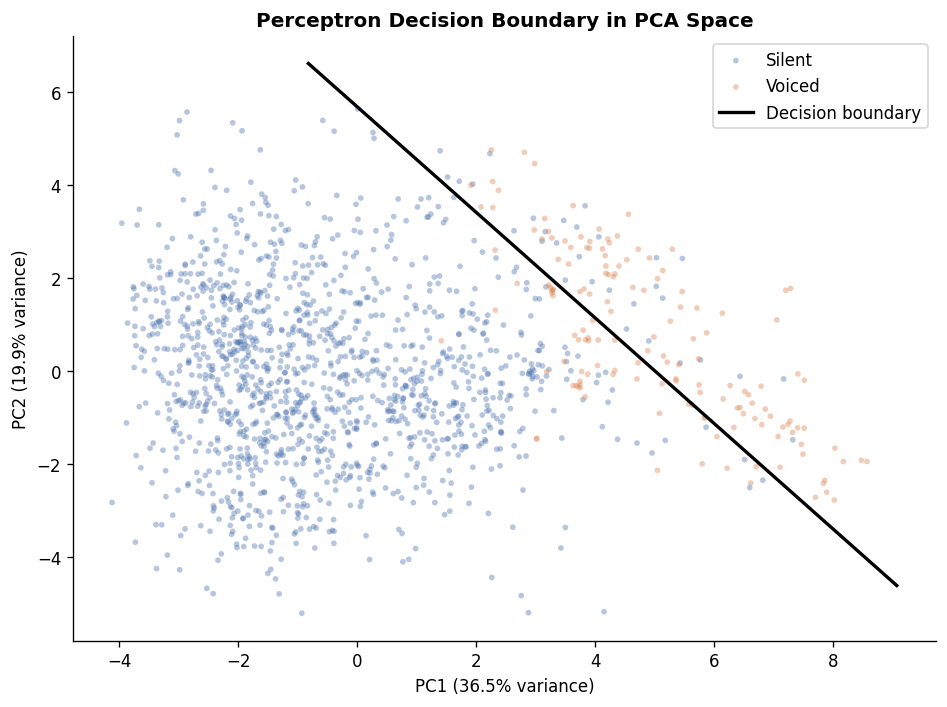

PC1 + PC2 explain 56.4% of total variance.


In [17]:
# Subsample for speed
N_VIZ = 1500
idx = rng.choice(len(X_train_sc), N_VIZ, replace=False)
X_sub, y_sub = X_train_sc[idx], y_train_perc[idx]

pca = PCA(n_components=2, random_state=SEED)
X2 = pca.fit_transform(X_sub)
X2_test = pca.transform(X_test_sc)

np.random.seed(SEED)
p2d = Perceptron(eta=0.1, epochs=100)
p2d.train(X2, y_sub)

# Decision boundary: w[0]*x + w[1]*y + b = 0  →  y = -(w[0]*x + b) / w[1]
x_range = np.linspace(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5, 300)
if abs(p2d.w_b_[1]) > 1e-10:
    y_boundary = -(p2d.w_b_[0] * x_range + p2d.w_b_[-1]) / p2d.w_b_[1]
else:
    y_boundary = None

fig, ax = plt.subplots(figsize=(8, 6))
colors = {-1: "#4C72B0", 1: "#DD8452"}
labels_viz = {-1: "Silent", 1: "Voiced"}
for cls in [-1, 1]:
    mask = y_sub == cls
    ax.scatter(X2[mask, 0], X2[mask, 1], c=colors[cls], label=labels_viz[cls],
               alpha=0.4, s=12, edgecolors="none")

if y_boundary is not None:
    clip_mask = (y_boundary >= X2[:, 1].min() - 1) & (y_boundary <= X2[:, 1].max() + 1)
    ax.plot(x_range[clip_mask], y_boundary[clip_mask], "k-", linewidth=2,
            label="Decision boundary")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Perceptron Decision Boundary in PCA Space", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"PC1 + PC2 explain {sum(pca.explained_variance_ratio_[:2]):.1%} of total variance.")

**Interpretation:** The PCA projection reveals that silent and voiced frames form two rough clusters in the first two principal components — the dominant direction (PC1) likely aligns with overall energy, which is the strongest discriminator. The decision boundary is a line through this 2D space, corresponding to a 17D hyperplane in the full feature space.

Note that some overlap between classes is visible in 2D. The full 18D model can exploit all directions and typically achieves higher accuracy — the 2D visualisation understates the true separability.

## 11. Summary

| | |
|---|---|
| **Algorithm** | Perceptron (Rosenblatt 1958) |
| **Task** | Binary voiced/unvoiced note detection |
| **Features** | 18 audio features per 46 ms frame (RMS, ZCR, spectral, MFCCs) |
| **Training data** | 10 GuitarSet tracks, string 0 (low E) |
| **Class balance** | 90.1% silent, 9.9% voiced |
| **Hyperparameters** | η = 0.0005, max_epochs = 200 |

**Takeaways:**

1. **The data is nearly but not perfectly linearly separable.** The perceptron did not converge to zero training error — the overlap near RMS=0, where quiet voiced frames resemble silence, prevents any single hyperplane from perfectly separating every sample. This is a limitation of the task itself, not the implementation.

2. **Non-convergence does not mean the model failed.** The mistakes curve plateaus early, indicating the boundary stabilized quickly and the remaining errors come from a small set of genuinely ambiguous frames. The final training error rate of 4.1% (687 out of 16,609 samples) reflects a real boundary, not random predictions.

3. **The results hold up at scale.** Evaluated on 943,812 unseen frames across all 360 GuitarSet tracks with no retraining, the model achieves 0.78 F1 — only 7 points below the subset test score. The core signal (energy and spectral shape) generalizes across players and playing styles.

4. **Accuracy is the wrong metric here.** With 90% silence, predicting silence always scores 90% — our model's F1 of 0.85 confirms it is doing real work on the minority voiced class, not just exploiting the imbalance.

5. **This is the right starting point, but not the ceiling.** The perceptron is a strong baseline for binary voiced/silent detection, but it cannot complete more complex tasks such as identifying which note is being played.